In [1]:
#Specify the PDB ID
pdb_id = 'pdb4zqk.ent'
path_to_structure = '../data/structures/'+pdb_id


In [2]:
# ============================================================
# Cell 1: Load and inspect the PD-1/PD-L1 complex
# ============================================================
from Bio.PDB import PDBParser, PDBIO, Select, NeighborSearch
from Bio.PDB.Polypeptide import is_aa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

parser = PDBParser(QUIET=True)
structure = parser.get_structure('complex', path_to_structure)
model = structure[0]  # first (and usually only) model

# Inventory the chains
for chain in model:
    residues = [r for r in chain.get_residues() if is_aa(r, standard=True)]
    print(f"Chain {chain.id}: {len(residues)} standard amino acid residues")
    # Print first and last residue numbers to understand numbering
    if residues:
        print(f"  Residue range: {residues[0].id[1]} — {residues[-1].id[1]}")

Chain A: 115 standard amino acid residues
  Residue range: 18 — 132
Chain B: 106 standard amino acid residues
  Residue range: 33 — 146


In [3]:
# ============================================================
# Cell 2: Identify interface residues
# ============================================================
# Interface = residues on PD-L1 that have atoms within 5Å of any PD-1 atom
# This is the surface your mini binder needs to compete with

DISTANCE_CUTOFF = 5.0  # Angstroms — standard interface cutoff

# IMPORTANT: Update these chain IDs after inspecting Cell 1 output
PDL1_CHAIN = 'A'  # <-- verify from Cell 1
PD1_CHAIN = 'B'   # <-- verify from Cell 1

pdl1_chain = model[PDL1_CHAIN]
pd1_chain = model[PD1_CHAIN]

# Get all atoms from PD-1 (the natural binding partner)
pd1_atoms = [atom for residue in pd1_chain.get_residues()
             if is_aa(residue, standard=True)
             for atom in residue.get_atoms()]

# Build neighbor search from PD-1 atoms
ns = NeighborSearch(pd1_atoms)

# Find PD-L1 residues within cutoff of any PD-1 atom
interface_residues = set()
for residue in pdl1_chain.get_residues():
    if not is_aa(residue, standard=True):
        continue
    for atom in residue.get_atoms():
        neighbors = ns.search(atom.get_vector().get_array(), DISTANCE_CUTOFF)
        if neighbors:
            interface_residues.add(residue.id[1])
            break  # one contact is enough to call it interface

interface_residues = sorted(interface_residues)
print(f"PD-L1 interface residues ({len(interface_residues)} total):")
print(interface_residues)

PD-L1 interface residues (22 total):
[18, 19, 20, 23, 26, 54, 56, 58, 63, 66, 76, 113, 115, 117, 119, 120, 121, 122, 123, 124, 125, 126]


In [4]:
# ============================================================
# Cell 3: Characterize interface residues
# ============================================================
# Build a table of interface residue properties

interface_data = []
for resnum in interface_residues:
    residue = pdl1_chain[(' ', resnum, ' ')]
    resname = residue.get_resname()

    # Classify residue type
    hydrophobic = resname in ['ALA', 'VAL', 'LEU', 'ILE', 'MET', 'PHE', 'TRP', 'PRO']
    polar = resname in ['SER', 'THR', 'ASN', 'GLN', 'TYR', 'CYS']
    charged = resname in ['ASP', 'GLU', 'LYS', 'ARG', 'HIS']

    rtype = 'hydrophobic' if hydrophobic else ('polar' if polar else ('charged' if charged else 'other'))

    # Calculate per-residue SASA contribution would go here in a full analysis
    # For now, just catalog what's there

    interface_data.append({
        'resnum': resnum,
        'resname': resname,
        'type': rtype
    })

df_interface = pd.DataFrame(interface_data)
print(df_interface.to_string(index=False))
print(f"\nComposition: {df_interface['type'].value_counts().to_dict()}")

 resnum resname        type
     18     ALA hydrophobic
     19     PHE hydrophobic
     20     THR       polar
     23     VAL hydrophobic
     26     ASP     charged
     54     ILE hydrophobic
     56     TYR       polar
     58     GLU     charged
     63     ASN       polar
     66     GLN       polar
     76     VAL hydrophobic
    113     ARG     charged
    115     MET hydrophobic
    117     SER       polar
    119     GLY       other
    120     GLY       other
    121     ALA hydrophobic
    122     ASP     charged
    123     TYR       polar
    124     LYS     charged
    125     ARG     charged
    126     ILE hydrophobic

Composition: {'hydrophobic': 8, 'polar': 6, 'charged': 6, 'other': 2}


In [5]:
# ============================================================
# Cell 4: Define hotspot residues for RFdiffusion
# ============================================================
# Hotspot residues = the subset of interface residues you MOST want
# your binder to contact. RFdiffusion uses these to guide design.
#
# Selection criteria (use your structural biology judgment):
# - Residues that contribute most to binding energy (large hydrophobic
#   sidechains, key hydrogen bonds)
# - Residues in the center of the interface (not periphery)
# - Avoid flexible loops at the edge of the interface
#
# The PD-1/PD-L1 interface is dominated by:
# - A hydrophobic patch (Ile54, Tyr56, Met115, Ala121, Tyr123 on PD-L1)
# - Key hydrogen bonds (Asp122, Arg125 on PD-L1)
#
# IMPORTANT: Verify these residue numbers against YOUR structure.
# Numbering can differ between PDB files due to expression constructs.

# Start with the full interface, then narrow down
# You'll refine this list after visual inspection in PyMOL (Step 3.4)

hotspot_candidates = interface_residues  # start with all, refine after visualization

print("Candidate hotspot residues (refine after PyMOL inspection):")
for resnum in hotspot_candidates:
    res = pdl1_chain[(' ', resnum, ' ')]
    print(f"  {res.get_resname()} {resnum}")

Candidate hotspot residues (refine after PyMOL inspection):
  ALA 18
  PHE 19
  THR 20
  VAL 23
  ASP 26
  ILE 54
  TYR 56
  GLU 58
  ASN 63
  GLN 66
  VAL 76
  ARG 113
  MET 115
  SER 117
  GLY 119
  GLY 120
  ALA 121
  ASP 122
  TYR 123
  LYS 124
  ARG 125
  ILE 126


In [6]:
# ============================================================
# Cell 5: Extract and save clean PD-L1 chain
# ============================================================
# Save just the PD-L1 chain as a clean PDB for RFdiffusion input

class ChainSelect(Select):
    def __init__(self, chain_id):
        self.chain_id = chain_id
    def accept_chain(self, chain):
        return chain.id == self.chain_id

io = PDBIO()
io.set_structure(structure)
output_path = '../data/structures/pdl1_clean.pdb'
io.save(output_path, ChainSelect(PDL1_CHAIN))
print(f"Saved clean PD-L1 chain to {output_path}")

Saved clean PD-L1 chain to ../data/structures/pdl1_clean.pdb


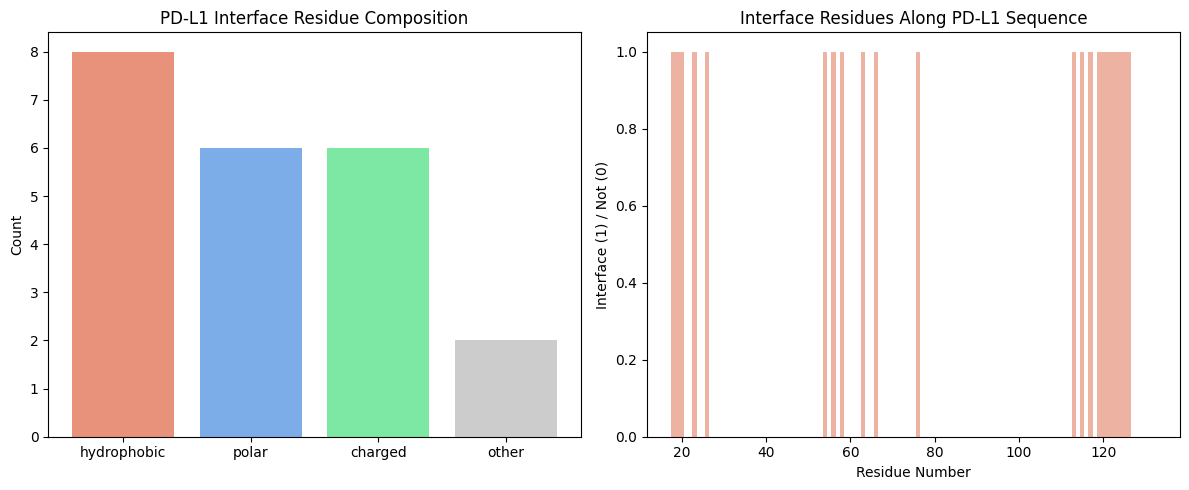

Saved figure to ../figures/pdl1_interface_characterization.png


In [7]:
# ============================================================
# Cell 6: Visualize the interface (matplotlib summary)
# ============================================================
# This gives you a quick visual; detailed inspection happens in PyMOL

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel 1: Interface residue composition
type_counts = df_interface['type'].value_counts()
colors = {'hydrophobic': '#E8927C', 'polar': '#7CADE8', 'charged': '#7CE8A3', 'other': '#CCCCCC'}
axes[0].bar(type_counts.index, type_counts.values,
            color=[colors.get(t, '#CCCCCC') for t in type_counts.index])
axes[0].set_title('PD-L1 Interface Residue Composition')
axes[0].set_ylabel('Count')

# Panel 2: Interface residues along sequence
all_resnums = [r.id[1] for r in pdl1_chain.get_residues() if is_aa(r, standard=True)]
is_interface = [1 if r in interface_residues else 0 for r in all_resnums]
axes[1].bar(all_resnums, is_interface, width=1.0, color='#E8927C', alpha=0.7)
axes[1].set_title('Interface Residues Along PD-L1 Sequence')
axes[1].set_xlabel('Residue Number')
axes[1].set_ylabel('Interface (1) / Not (0)')

plt.tight_layout()
plt.savefig('../figures/pdl1_interface_characterization.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved figure to ../figures/pdl1_interface_characterization.png")